<a href="https://colab.research.google.com/github/Thrilcrazyer/Data_Structures_2026/blob/main/Code/ArrayMax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. 개발 환경
- 본 실습에서 개발 환경은 Python 에서 기본적으로 제공하는 Tool인 IDLE로 제한합니다.


[설치링크](https://www.python.org/downloads/)




# 1. 배열(Array)
- **동일한 타입**의 데이터를 **연속된 메모리 공간**에 저장하는 자료구조

### 배열의 구조

| 인덱스 | 0 | 1 | 2 | 3 | 4 | $\cdots$ | n−1 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **값** | A[0] | A[1] | A[2] | A[3] | A[4] | $\cdots$ | A[n−1] |
| **주소** | base | base+4 | base+8 | base+12 | base+16 | $\cdots$ | base+4(n−1) |

- `int`형 기준 각 원소는 **4바이트** 크기이므로, 주소가 4씩 증가

### 주소 계산 공식

$$\text{addr}(A[i]) = \text{base address} + i \times \text{sizeof(element)}$$


### Python에서의 배열

- Python은 `list`라는 내장 자료구조를 통해 배열 기능을 제공하며, 본 강의에서 다루는 **Array**보다 상위 개념으로 구현되어 있습니다.
- 이 내용은 **Vector** 강의에서 추가로 설명합니다.
- 본 실습에서는 ctypes.Array를 통해 Array를 구현합니다

In [1]:
import random
import ctypes

n= int(input("몇 개의 숫자를 생성할까요?"))

## C Style
### 배열을 생성

In [2]:
# 배열 선언
ArrayType = ctypes.c_int * n
A = ArrayType()

# 데이터 입력
for i in range(n):
  A[i] = random.randint(1, 100)

### 생성된 배열을 확인

In [3]:
print(A)

A_addr = ctypes.addressof(A)

for i in range(n):
    addr = A_addr + i * ctypes.sizeof(ctypes.c_int)
    print(f"{i}번째 주소: {addr}")
    print(f"{i}번째 주소의 값: {ctypes.c_int.from_address(addr).value}, 값: {A[i]}")

0번째 주소: 140115310633744
0번째 주소의 값: 34, 값: 34
1번째 주소: 140115310633748
1번째 주소의 값: 17, 값: 17
2번째 주소: 140115310633752
2번째 주소의 값: 45, 값: 45
3번째 주소: 140115310633756
3번째 주소의 값: 56, 값: 56
4번째 주소: 140115310633760
4번째 주소의 값: 64, 값: 64
5번째 주소: 140115310633764
5번째 주소의 값: 19, 값: 19
6번째 주소: 140115310633768
6번째 주소의 값: 67, 값: 67
7번째 주소: 140115310633772
7번째 주소의 값: 70, 값: 70
8번째 주소: 140115310633776
8번째 주소의 값: 34, 값: 34
9번째 주소: 140115310633780
9번째 주소의 값: 28, 값: 28


## Pythonic Style

### 리스트 형태의 배열을 생성

In [4]:
A = [random.randint(1, 100) for i in range(n)]

print(A)

[44, 11, 76, 13, 92, 68, 5, 71, 38, 16]


## 코드 실습

`DS_AL_ch1_algorithm기초_U.pdf, 17 page`

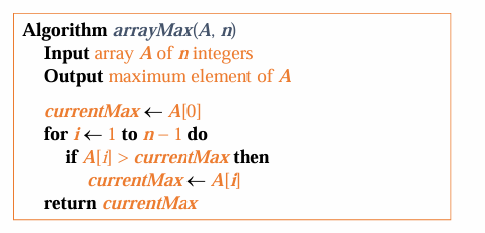

In [5]:
def arrayMax(A:ctypes.Array, n:int) -> int:
    currentMax=A[0]
    for i in range(1, n):
        if A[i] > currentMax:
            currentMax = A[i]
    return currentMax

print(arrayMax(A, n))

92


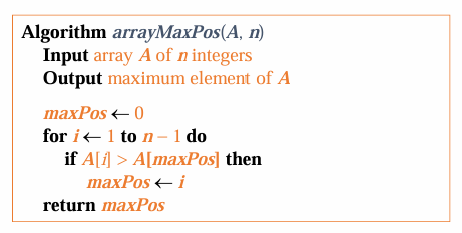

In [ ]:
index=int

def arrayMaxPos(A:ctypes.Array, n:int) -> index:
    maxPos: index = 0
    for i in range(1,n):
        if A[i] > A[maxPos]:
            maxPos = i
    return maxPos

print(arrayMaxPos(A, n))

4


`DS_AL_ch1_algorithm기초_U.pdf, 21 page`

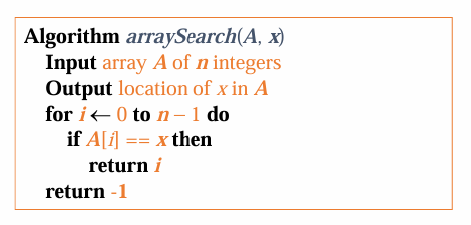

In [ ]:
def arraySearch(A:ctypes.Array, n:int, key:int) -> index:
    for i in range(n):
        if A[i] == key:
            return i
    return -1

`DS_AL_ch1_algorithm기초_U.pdf, 24 page`

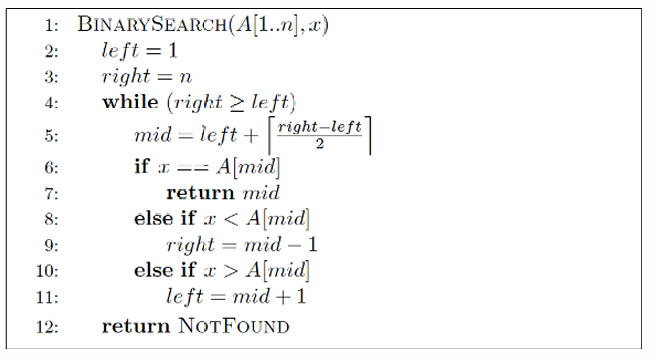

In [14]:
def binarySearch(A:ctypes.Array,n:int,x:int) -> index:
    left=0
    right=n-1
    while right >= left:
        middle=(left+right)//2
        if A[middle] == x:
            return middle
        elif A[middle] < x:
            left = middle + 1
        else:
            right = middle - 1
    return "404 New Error ERA"

print(binarySearch(A, n, 11))

1


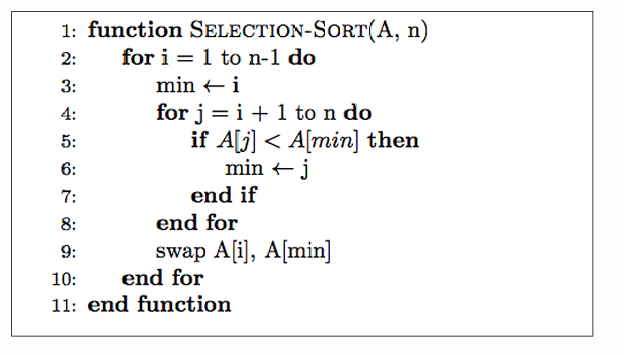

In [ ]:
def selectionSort(A:ctypes.Array, n:int) -> None:
    for i in range(n-1):
        minPos = i
        for j in range(i+1, n):
            if A[j] < A[minPos]:
                minPos = j
        A[i], A[minPos] = A[minPos], A[i]


######################################################

n=10
A = (ctypes.c_int * n)()

for i in range(n):
    A[i] = random.randint(1, 100)
    print(A[i], end=' ')

print()

selectionSort(A, n)

for i in range(n):
    print(A[i], end=' ')

53 1 22 29 89 17 3 46 44 74 
1 3 17 22 29 44 46 53 74 89 